In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

df = pd.read_csv("Meghana_Feature_Engineered.csv")

df["Month"] = pd.to_datetime(df["Month"])

df = df.sort_values(["Branch_Name", "Month"])

df.head()

,Branch_ID,Branch_Name,Region,Month,Orders,Revenue,Avg_Rating,Customer_Count,Repeat_Customers,New_Customers,...,Complaint_Rate_Pct,New_Customer_Rate,New_Customer_Rate_Pct,Service_Quality_Score,Customer_Acquisition_Score,Complaint_Per_1000_Orders,Revenue_Growth_Pct,Repeat_Customer_Growth_Pct,Churn_Risk,Operational_Risk
0,E_01,Electronic City,South,2024-01-01,6733,2316152,3.7,5639,2706,2933,...,3.39,0.5201,52.01,67.22,52.01,33.863063,0.000000,0.000000,High,High
1,E_02,Electronic City,South,2024-02-01,5483,2121921,3.8,4382,1928,2454,...,3.41,0.5600,56.00,69.18,56.00,34.105417,-8.385935,-28.750924,High,High
2,E_03,Electronic City,South,2024-03-01,4953,2060448,4.0,4240,1865,2375,...,3.98,0.5601,56.01,72.04,56.01,39.773874,-2.897045,-3.267635,Medium,High
3,E_04,Electronic City,South,2024-04-01,5824,2364544,3.8,4517,2213,2304,...,4.16,0.5101,51.01,67.68,51.01,41.552198,14.758732,18.659517,High,High
4,E_05,Electronic City,South,2024-05-01,6389,2287262,3.9,5487,2469,3018,...,3.54,0.5500,55.00,70.92,55.00,35.373298,-3.268368,11.568007,High,Medium


In [14]:
df.columns

Index(['Unnamed: 0', 'Branch_ID', 'Branch_Name', 'Region', 'Month', 'Orders',
       'Revenue', 'Avg_Rating', 'Customer_Count', 'Repeat_Customers',
       'New_Customers', 'Complaints', 'Delivery_Time_Min', 'Performance_Level',
       'Branch_Status', 'Reason', 'Revenue_Per_Order', 'Revenue_Per_Customer',
       'Customer_Loyalty_Score', 'Operational_Risk_Score',
       'Repeat_Customer_Rate', 'Repeat_Customer_Rate_Pct', 'Complaint_Rate',
       'Complaint_Rate_Pct', 'New_Customer_Rate', 'New_Customer_Rate_Pct',
       'Service_Quality_Score', 'Customer_Acquisition_Score',
       'Complaint_Per_1000_Orders', 'Revenue_Growth_Pct',
       'Repeat_Customer_Growth_Pct', 'Churn_Risk', 'Operational_Risk'],
      dtype='object')

In [20]:
df = df.drop(columns=['Unnamed: 0'])


In [37]:
df[
    [
        "Branch_Name",
        "Month",
        "Orders",
        "Revenue",
        "Avg_Rating",
        "Repeat_Customer_Rate_Pct",
        "Operational_Risk_Score",
        "Complaints",
        "Delivery_Time_Min",
        "Operational_Risk"
    ]
    
].head()

,Branch_Name,Month,Orders,Revenue,Avg_Rating,Repeat_Customer_Rate_Pct,Operational_Risk_Score,Complaints,Delivery_Time_Min,Operational_Risk
0,Electronic City,2024-01-01,6733,2316152,3.7,47.99,39.333863,228,43,High
1,Electronic City,2024-02-01,5483,2121921,3.8,44.00,39.234105,187,43,High
2,Electronic City,2024-03-01,4953,2060448,4.0,43.99,43.039774,197,47,High
3,Electronic City,2024-04-01,5824,2364544,3.8,48.99,34.241552,242,38,High
4,Electronic City,2024-05-01,6389,2287262,3.9,45.00,32.135373,226,36,Medium


In [38]:
df.columns


Index(['Branch_ID', 'Branch_Name', 'Region', 'Month', 'Orders', 'Revenue',
       'Avg_Rating', 'Customer_Count', 'Repeat_Customers', 'New_Customers',
       'Complaints', 'Delivery_Time_Min', 'Performance_Level', 'Branch_Status',
       'Reason', 'Revenue_Per_Order', 'Revenue_Per_Customer',
       'Customer_Loyalty_Score', 'Operational_Risk_Score',
       'Repeat_Customer_Rate', 'Repeat_Customer_Rate_Pct', 'Complaint_Rate',
       'Complaint_Rate_Pct', 'New_Customer_Rate', 'New_Customer_Rate_Pct',
       'Service_Quality_Score', 'Customer_Acquisition_Score',
       'Complaint_Per_1000_Orders', 'Revenue_Growth_Pct',
       'Repeat_Customer_Growth_Pct', 'Churn_Risk', 'Operational_Risk'],
      dtype='object')

In [39]:
branch_summary = (
    df.groupby("Branch_Name")
      .agg({
          "Orders":"mean",
          "Revenue":"mean",
          "Avg_Rating":"mean",
          "Repeat_Customer_Rate_Pct":"mean",
          "Complaints":"mean",
          "Delivery_Time_Min":"mean",
          "Operational_Risk_Score":"mean"
      })
      .reset_index()
)

branch_summary

,Branch_Name,Orders,Revenue,Avg_Rating,Repeat_Customer_Rate_Pct,Complaints,Delivery_Time_Min,Operational_Risk_Score
0,Electronic City,5956.041667,2.279874e+06,3.854167,44.157917,206.916667,41.583333,37.764659
1,Indiranagar,14065.000000,5.653330e+06,4.645833,71.746667,57.666667,20.916667,16.274963
2,Jayanagar,14331.583333,5.491272e+06,4.654167,71.413750,60.916667,21.791667,17.141825
3,Kalyan Nagar,5830.875000,2.228302e+06,3.854167,45.155000,193.708333,40.958333,37.138190
4,Kanakapura Road,9496.750000,3.583253e+06,4.279167,60.201667,113.291667,31.166667,26.899580
5,Koramangala,14379.541667,5.501837e+06,4.683333,70.997083,67.208333,22.125000,17.446375
6,Mahadevapura,6124.208333,2.330320e+06,3.866667,44.030833,203.250000,42.916667,39.083632
7,Marathahalli,10099.250000,3.759939e+06,4.287500,59.117500,111.250000,30.416667,26.140354
8,Rajarajeshwari Nagar,5922.958333,2.254104e+06,3.825000,44.825417,205.791667,41.416667,37.627226
9,Residency Road,13889.625000,5.395962e+06,4.645833,71.912917,62.541667,21.250000,16.608725


In [40]:
def classify_branch(row):

    if (
        row["Avg_Rating"] >= 4.5
        and row["Repeat_Customer_Rate_Pct"] >= 65
        and row["Operational_Risk_Score"] <= 20
    ):
        return "High Performing Stable"

    elif (
        row["Avg_Rating"] >= 4.1
        and row["Repeat_Customer_Rate_Pct"] >= 55
    ):
        return "Growing Branch"

    else:
        return "Recovery Required"

branch_summary["Branch_Category"] = branch_summary.apply(
    classify_branch,
    axis=1
)

In [41]:
branch_summary[
[
"Branch_Name",
"Avg_Rating",
"Repeat_Customer_Rate_Pct",
"Operational_Risk_Score",
"Branch_Category"
]
]

,Branch_Name,Avg_Rating,Repeat_Customer_Rate_Pct,Operational_Risk_Score,Branch_Category
0,Electronic City,3.854167,44.157917,37.764659,Recovery Required
1,Indiranagar,4.645833,71.746667,16.274963,High Performing Stable
2,Jayanagar,4.654167,71.413750,17.141825,High Performing Stable
3,Kalyan Nagar,3.854167,45.155000,37.138190,Recovery Required
4,Kanakapura Road,4.279167,60.201667,26.899580,Growing Branch
5,Koramangala,4.683333,70.997083,17.446375,High Performing Stable
6,Mahadevapura,3.866667,44.030833,39.083632,Recovery Required
7,Marathahalli,4.287500,59.117500,26.140354,Growing Branch
8,Rajarajeshwari Nagar,3.825000,44.825417,37.627226,Recovery Required
9,Residency Road,4.645833,71.912917,16.608725,High Performing Stable


In [42]:
def forecast_branch_orders(branch_name):

    branch_df = df[df["Branch_Name"] == branch_name].copy()
    branch_df = branch_df.sort_values("Month")

    ts = branch_df.set_index("Month")["Orders"]

    model = ExponentialSmoothing(
        ts,
        trend="add",
        seasonal="add",
        seasonal_periods=12
    )

    fitted_model = model.fit()

    forecast = fitted_model.forecast(3)

    return forecast

In [43]:
forecast_results = []

for branch in df["Branch_Name"].unique():

    branch_df = df[df["Branch_Name"] == branch].copy()
    branch_df = branch_df.sort_values("Month")

    # Current monthly orders = latest actual month, Dec 2025
    current_orders = int(branch_df.iloc[-1]["Orders"])

    # Forecast next 3 months: Jan, Feb, Mar 2026
    forecast = forecast_branch_orders(branch)

    forecast_results.append({
        "Branch_Name": branch,
        "Current_Monthly_Orders": current_orders,
        "Forecast_Jan_2026_Orders": int(forecast.iloc[0]),
        "Forecast_Q1_2026_Orders": int(forecast.sum())
    })

forecast_df = pd.DataFrame(forecast_results)

forecast_df.head()

C:\Users\Karishma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Karishma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Karishma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Karishma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Karishma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS w

,Branch_Name,Current_Monthly_Orders,Forecast_Jan_2026_Orders,Forecast_Q1_2026_Orders
0,Electronic City,5779,5530,14372
1,Indiranagar,14748,15896,42789
2,Jayanagar,17221,15712,42208
3,Kalyan Nagar,7016,6329,18367
4,Kanakapura Road,10108,11549,31917


In [44]:
current_orders = (
    df.sort_values("Month")
      .groupby("Branch_Name")
      .tail(1)[["Branch_Name", "Orders"]]
)

final_df = forecast_df.merge(current_orders, on="Branch_Name", how="left")

In [45]:
final_df = final_df.merge(
    branch_summary[["Branch_Name", "Branch_Category"]],
    on="Branch_Name",
    how="left"
)

In [46]:
def demand_trend(category):
    if category == "High Performing Stable":
        return "Stable High Demand"
    elif category == "Growing Branch":
        return "Growing"
    else:
        return "Declining / Unstable"


def forecast_confidence(category):
    if category == "High Performing Stable":
        return "High"
    elif category == "Growing Branch":
        return "Medium"
    else:
        return "Low"


def capacity_status(category):
    if category == "High Performing Stable":
        return "Optimized"
    elif category == "Growing Branch":
        return "Expansion Required"
    else:
        return "Recovery Required"


final_df["Demand_Trend"] = final_df["Branch_Category"].apply(demand_trend)
final_df["Forecast_Confidence"] = final_df["Branch_Category"].apply(forecast_confidence)
final_df["Capacity_Status"] = final_df["Branch_Category"].apply(capacity_status)

In [47]:
final_df[
    [
        "Branch_Name",
        "Current_Monthly_Orders",
        "Forecast_Jan_2026_Orders",
        "Forecast_Q1_2026_Orders",
        "Branch_Category",
        "Demand_Trend",
        "Forecast_Confidence",
        "Capacity_Status"
    ]
]

,Branch_Name,Current_Monthly_Orders,Forecast_Jan_2026_Orders,Forecast_Q1_2026_Orders,Branch_Category,Demand_Trend,Forecast_Confidence,Capacity_Status
0,Electronic City,5779,5530,14372,Recovery Required,Declining / Unstable,Low,Recovery Required
1,Indiranagar,14748,15896,42789,High Performing Stable,Stable High Demand,High,Optimized
2,Jayanagar,17221,15712,42208,High Performing Stable,Stable High Demand,High,Optimized
3,Kalyan Nagar,7016,6329,18367,Recovery Required,Declining / Unstable,Low,Recovery Required
4,Kanakapura Road,10108,11549,31917,Growing Branch,Growing,Medium,Expansion Required
5,Koramangala,15409,16018,44946,High Performing Stable,Stable High Demand,High,Optimized
6,Mahadevapura,6494,5304,16879,Recovery Required,Declining / Unstable,Low,Recovery Required
7,Marathahalli,11068,11975,29156,Growing Branch,Growing,Medium,Expansion Required
8,Rajarajeshwari Nagar,7520,7094,17348,Recovery Required,Declining / Unstable,Low,Recovery Required
9,Residency Road,15207,15964,41294,High Performing Stable,Stable High Demand,High,Optimized


In [48]:
def plot_branch_forecast(branch_name):

    branch_df = df[df["Branch_Name"] == branch_name].copy()
    branch_df = branch_df.sort_values("Month")

    forecast = forecast_branch_orders(branch_name)

    plt.figure(figsize=(12, 5))

    plt.plot(
        branch_df["Month"],
        branch_df["Orders"],
        marker="o",
        label="Actual Orders 2024-2025"
    )

    plt.plot(
        forecast.index,
        forecast.values,
        marker="o",
        linestyle="--",
        label="Forecast Orders 2026"
    )

    lower_range = forecast * 0.95
    upper_range = forecast * 1.05

    plt.fill_between(
        forecast.index,
        lower_range,
        upper_range,
        alpha=0.2,
        label="Forecast Range"
    )

    plt.title(f"Demand Forecast Chart - {branch_name}")
    plt.xlabel("Month")
    plt.ylabel("Orders")
    plt.legend()
    plt.grid(True)
    plt.show()

C:\Users\Karishma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


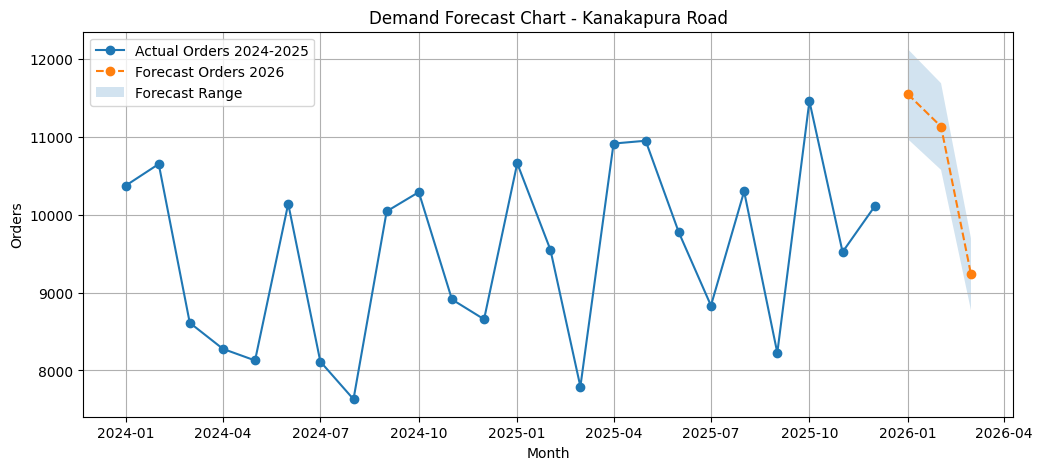

In [49]:
plot_branch_forecast("Kanakapura Road")

In [50]:
def get_branch_recommendations(category):

    if category == "High Performing Stable":
        return {
            "food": "No heavy inventory increase required. Maintain stock levels and focus on premium/high-margin items.",
            "staff": "No extra hiring required. Maintain current staff efficiency.",
            "delivery": "No additional riders required. Monitor peak-hour delivery speed.",
            "service": "Focus on premium packaging, faster handover, and consistent customer experience.",
            "combo": "Launch premium biryani combos and high-margin family packs.",
            "upsell": "Promote desserts, beverages, starters, and family packs.",
            "retention": "Strengthen loyalty program for repeat customers.",
            "marketing": "Avoid heavy discounts. Focus on premium positioning and customer loyalty.",
            "priorities": [
                "Profit Margin Improvement",
                "Premium Combo Strategy",
                "Customer Loyalty",
                "Service Consistency",
                "Brand Positioning"
            ],
            "benefits": [
                "Stable Order Capacity",
                "Better Profit Margin",
                "Higher Premium Sales",
                "Strong Customer Loyalty",
                "Consistent Ratings",
                "Improved Revenue Quality"
            ]
        }

    elif category == "Growing Branch":
        return {
            "food": "Increase inventory by approximately 10-15% for biryani rice, chicken, paneer, starters, soft drinks, and desserts.",
            "staff": "Add 1 kitchen assistant and 1 packing staff during Friday-Sunday evenings.",
            "delivery": "Keep 1-2 additional delivery riders available during 7 PM - 10 PM.",
            "service": "Prepare raita, salan, soft drinks, and cutlery packs before peak hours.",
            "combo": "Launch Family Biryani Combo to increase Average Order Value.",
            "upsell": "Promote desserts, beverages, and starters.",
            "retention": "Order Again Within 7 Days → Get ₹50 Coupon. Also run After 5 Orders → Free Dessert.",
            "marketing": "Run 2-hour limited offers during low-demand periods. Avoid discounts during peak hours.",
            "priorities": [
                "Inventory Preparation",
                "Delivery Preparation",
                "Staff Planning",
                "Customer Retention",
                "Marketing Expansion"
            ],
            "benefits": [
                "Higher Order Capacity",
                "Lower Delivery Delays",
                "Better Customer Ratings",
                "Increased Repeat Customers",
                "Reduced Customer Churn",
                "Improved Revenue Growth",
                "Better Operational Stability"
            ]
        }

    else:
        return {
            "food": "Do not increase inventory heavily. Control wastage and focus only on fast-moving items.",
            "staff": "No new hiring recommended now. Improve current staff efficiency first.",
            "delivery": "Fix delivery delays before adding extra riders. Track delayed orders closely.",
            "service": "Reduce complaints, improve packing accuracy, and monitor low-rating orders.",
            "combo": "Use simple value combos to recover lost customers instead of premium combos.",
            "upsell": "Promote affordable add-ons only after service issues improve.",
            "retention": "Run win-back offers for inactive customers: We Miss You Offer → Get ₹50 Off On Next Order.",
            "marketing": "Avoid aggressive marketing until complaints and service issues are reduced.",
            "priorities": [
                "Complaint Reduction",
                "Delivery Speed Improvement",
                "Rating Recovery",
                "Customer Win-Back",
                "Controlled Marketing"
            ],
            "benefits": [
                "Reduced Complaints",
                "Improved Delivery Performance",
                "Better Customer Trust",
                "Higher Repeat Customer Recovery",
                "Lower Operational Waste",
                "Improved Branch Stability"
            ]
        }

In [51]:
def demand_forecast_report(branch_name):

    branch_data = final_df[final_df["Branch_Name"] == branch_name]

    if branch_data.empty:
        print("Branch not found. Check spelling.")
        return

    row = branch_data.iloc[0]
    category = row["Branch_Category"]
    rec = get_branch_recommendations(category)

    print("=" * 85)
    print("DEMAND FORECAST REPORT")
    print("=" * 85)

    print("\nBranch:")
    print(branch_name)

    print("\nCurrent Monthly Orders:")
    print(f"{int(row['Current_Monthly_Orders']):,}")

    print("\nForecast Jan 2026 Orders:")
    print(f"{int(row['Forecast_Jan_2026_Orders']):,}")

    print("\nForecast Q1 2026 Orders:")
    print(f"{int(row['Forecast_Q1_2026_Orders']):,}")

    print("\nDemand Trend:")
    print(row["Demand_Trend"])

    print("\nForecast Confidence:")
    print(row["Forecast_Confidence"])

    print("\nCapacity Status:")
    print(row["Capacity_Status"])

    print("\nBranch Category:")
    print(category)

    print("=" * 85)

    print("\nFORECAST CHART\n")
    plot_branch_forecast(branch_name)

    print("=" * 85)
    print("\nDEMAND SITUATION\n")

    if category == "High Performing Stable":
        print(
            "Demand is expected to remain strong and stable during the next quarter.\n\n"
            "This branch already has strong customer loyalty, high ratings,\n"
            "and stable operational performance.\n\n"
            "The focus should be profit improvement, premium combos,\n"
            "and maintaining service consistency."
        )

    elif category == "Growing Branch":
        print(
            "Demand is expected to increase during the next quarter.\n\n"
            "More customers are expected to place orders from this branch.\n\n"
            "If the branch is not prepared, food shortages, delivery delays,\n"
            "and customer complaints may increase.\n\n"
            "This branch has growth momentum and should prepare for higher demand."
        )

    else:
        print(
            "Demand is weak or unstable compared to stronger branches.\n\n"
            "The branch should not focus on aggressive expansion immediately.\n\n"
            "The first priority is to reduce complaints, improve delivery speed,\n"
            "recover customer trust, and increase repeat orders."
        )

    print("=" * 85)
    print("\nWHAT THIS MEANS TO BUSINESS\n")

    if category == "High Performing Stable":
        print(
            "This branch is already performing well.\n\n"
            "Business focus should be:\n\n"
            "• Protecting customer experience\n"
            "• Improving profit margin\n"
            "• Increasing premium combo sales\n"
            "• Retaining loyal customers\n\n"
            "The branch should avoid unnecessary cost increase."
        )

    elif category == "Growing Branch":
        print(
            "This is a growth opportunity.\n\n"
            "Higher demand means:\n\n"
            "• More kitchen workload\n"
            "• More delivery workload\n"
            "• Higher inventory consumption\n"
            "• Increased customer expectations\n\n"
            "The branch should prepare resources before demand increases."
        )

    else:
        print(
            "This branch needs recovery before expansion.\n\n"
            "Current business focus should be:\n\n"
            "• Complaint reduction\n"
            "• Faster delivery\n"
            "• Better ratings\n"
            "• Repeat customer recovery\n"
            "• Controlled cost management\n\n"
            "The branch should avoid increasing operational cost too early."
        )

    print("=" * 85)
    print("\nOPERATIONAL ACTION PLAN\n")

    print("Food Preparation:")
    print(rec["food"])

    print("\nStaff Preparation:")
    print(rec["staff"])

    print("\nDelivery Preparation:")
    print(rec["delivery"])

    print("\nService Preparation:")
    print(rec["service"])

    print("=" * 85)
    print("\nREVENUE EXPANSION PLAN\n")

    print("Combo Strategy:")
    print(rec["combo"])

    print("\nUpselling Strategy:")
    print(rec["upsell"])

    print("=" * 85)
    print("\nCUSTOMER RETENTION PLAN\n")
    print(rec["retention"])

    print("=" * 85)
    print("\nMARKETING PLAN\n")
    print(rec["marketing"])

    print("=" * 85)
    print("\nPRIORITY ORDER\n")

    for i, priority in enumerate(rec["priorities"], start=1):
        print(f"Priority {i}:")
        print(priority)
        print()

    print("=" * 85)
    print("\nEXPECTED BUSINESS IMPACT\n")

    print("Expected Benefits:\n")
    for benefit in rec["benefits"]:
        print(f"• {benefit}")

    print("=" * 85)

DEMAND FORECAST REPORT

Branch:
Koramangala

Current Monthly Orders:
15,409

Forecast Jan 2026 Orders:
16,018

Forecast Q1 2026 Orders:
44,946

Demand Trend:
Stable High Demand

Forecast Confidence:
High

Capacity Status:
Optimized

Branch Category:
High Performing Stable

FORECAST CHART



C:\Users\Karishma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


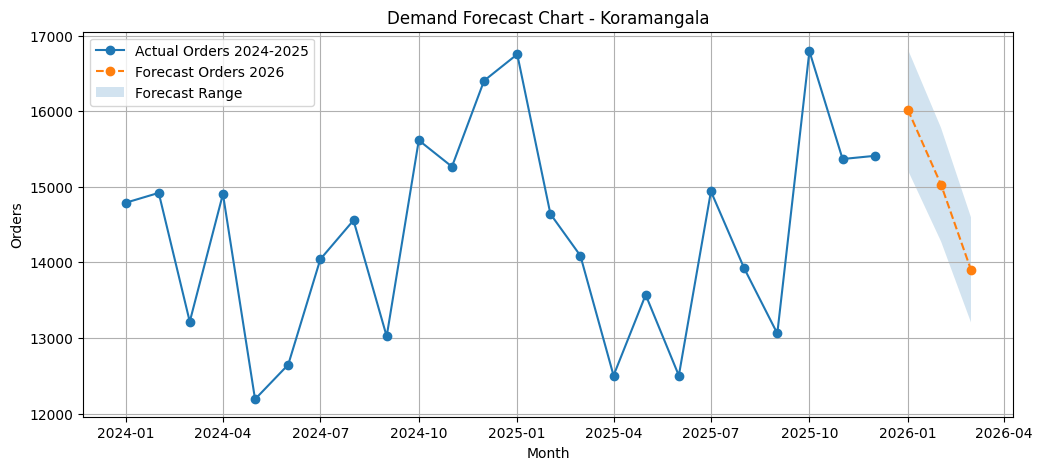


DEMAND SITUATION

Demand is expected to remain strong and stable during the next quarter.

This branch already has strong customer loyalty, high ratings,
and stable operational performance.

The focus should be profit improvement, premium combos,
and maintaining service consistency.

WHAT THIS MEANS TO BUSINESS

This branch is already performing well.

Business focus should be:

• Protecting customer experience
• Improving profit margin
• Increasing premium combo sales
• Retaining loyal customers

The branch should avoid unnecessary cost increase.

OPERATIONAL ACTION PLAN

Food Preparation:
No heavy inventory increase required. Maintain stock levels and focus on premium/high-margin items.

Staff Preparation:
No extra hiring required. Maintain current staff efficiency.

Delivery Preparation:
No additional riders required. Monitor peak-hour delivery speed.

Service Preparation:
Focus on premium packaging, faster handover, and consistent customer experience.

REVENUE EXPANSION PLAN

Comb

In [52]:
demand_forecast_report("Koramangala")

DEMAND FORECAST REPORT

Branch:
Kanakapura Road

Current Monthly Orders:
10,108

Forecast Jan 2026 Orders:
11,549

Forecast Q1 2026 Orders:
31,917

Demand Trend:
Growing

Forecast Confidence:
Medium

Capacity Status:
Expansion Required

Branch Category:
Growing Branch

FORECAST CHART



C:\Users\Karishma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


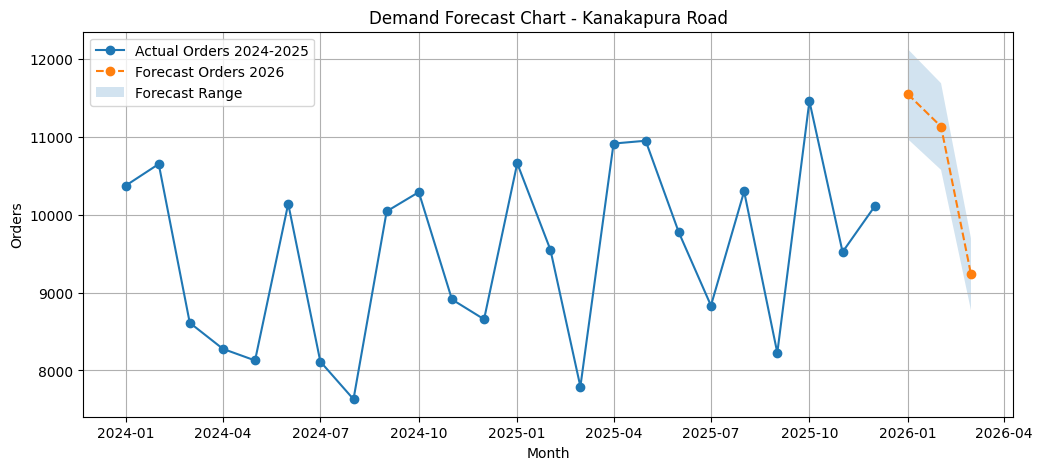


DEMAND SITUATION

Demand is expected to increase during the next quarter.

More customers are expected to place orders from this branch.

If the branch is not prepared, food shortages, delivery delays,
and customer complaints may increase.

This branch has growth momentum and should prepare for higher demand.

WHAT THIS MEANS TO BUSINESS

This is a growth opportunity.

Higher demand means:

• More kitchen workload
• More delivery workload
• Higher inventory consumption
• Increased customer expectations

The branch should prepare resources before demand increases.

OPERATIONAL ACTION PLAN

Food Preparation:
Increase inventory by approximately 10-15% for biryani rice, chicken, paneer, starters, soft drinks, and desserts.

Staff Preparation:
Add 1 kitchen assistant and 1 packing staff during Friday-Sunday evenings.

Delivery Preparation:
Keep 1-2 additional delivery riders available during 7 PM - 10 PM.

Service Preparation:
Prepare raita, salan, soft drinks, and cutlery packs before pea

In [53]:
demand_forecast_report("Kanakapura Road")

DEMAND FORECAST REPORT

Branch:
Electronic City

Current Monthly Orders:
5,779

Forecast Jan 2026 Orders:
5,530

Forecast Q1 2026 Orders:
14,372

Demand Trend:
Declining / Unstable

Forecast Confidence:
Low

Capacity Status:
Recovery Required

Branch Category:
Recovery Required

FORECAST CHART



C:\Users\Karishma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


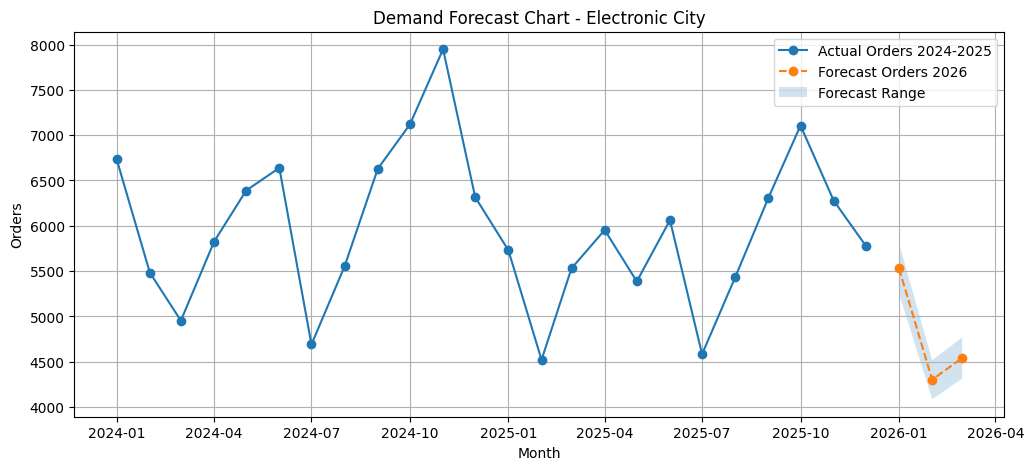


DEMAND SITUATION

Demand is weak or unstable compared to stronger branches.

The branch should not focus on aggressive expansion immediately.

The first priority is to reduce complaints, improve delivery speed,
recover customer trust, and increase repeat orders.

WHAT THIS MEANS TO BUSINESS

This branch needs recovery before expansion.

Current business focus should be:

• Complaint reduction
• Faster delivery
• Better ratings
• Repeat customer recovery
• Controlled cost management

The branch should avoid increasing operational cost too early.

OPERATIONAL ACTION PLAN

Food Preparation:
Do not increase inventory heavily. Control wastage and focus only on fast-moving items.

Staff Preparation:
No new hiring recommended now. Improve current staff efficiency first.

Delivery Preparation:
Fix delivery delays before adding extra riders. Track delayed orders closely.

Service Preparation:
Reduce complaints, improve packing accuracy, and monitor low-rating orders.

REVENUE EXPANSION PLAN

C

In [54]:
demand_forecast_report("Electronic City")

In [57]:
demand_forecast_output = final_df.copy()

demand_forecast_output.to_csv(
    "Meghana_Demand_Forecast_Output.csv",
    index=False
)

In [58]:
df.to_csv("Meghana_Feature_Engineered.csv",index=False)